# Module 3.17 — Turbulence Basics

**Why turbulence is the hardest problem in classical physics:**
Nearly every engineering flow is turbulent — yet there is no general analytical solution to the turbulent Navier-Stokes equations. The $1,000,000 Millennium Prize for solving N-S remains unclaimed.

**What makes turbulence hard:** it is simultaneously:
- **Multi-scale** — eddies exist from metres down to sub-millimetre sizes
- **Nonlinear** — eddies interact and exchange energy with each other
- **Chaotic** — tiny changes in initial conditions create completely different flow histories

**What this module covers:**
1. The energy cascade — structure of turbulence across scales
2. Reynolds decomposition — splitting mean from fluctuation
3. RANS equations — what turbulence does to the N-S equations
4. The closure problem — why turbulence models are needed
5. Boussinesq hypothesis — eddy viscosity as the simplest closure
6. Prandtl mixing-length model — the simplest turbulence model
7. Law of the wall — the universal near-wall velocity profile

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Energy Cascade

### What turbulence actually looks like

At low Reynolds number (Re = 100, your cavity flow), the flow has one smooth vortex. As Re increases, that vortex becomes unstable and breaks into smaller vortices. Those break into smaller ones. And so on — until you reach scales small enough for viscosity to act.

This is the **energy cascade** (Richardson, 1922):

```
Large eddies (size L)         Energy injected by mean shear
       ↓ break up
Medium eddies (size ℓ)         Energy transferred — no production or loss
       ↓ break up
Small eddies (size η)          Viscosity converts kinetic energy → heat
```

### Why eddies break up

A large eddy has Re >> 1 — inertia dominates. It is unstable and breaks apart (Kelvin-Helmholtz instability). The child eddies also have Re >> 1 and also break up. This continues until the eddies are small enough that Re ≈ 1 — viscosity can now act and dissipate the energy.

### Kolmogorov microscales (1941)

At what size does Re = 1? Using only $\nu$ [m²/s] and $\varepsilon$ [m²/s³] (the only relevant quantities):

$$\boxed{\eta = \left(\frac{\nu^3}{\varepsilon}\right)^{1/4}}$$

$$u_\eta = (\nu\,\varepsilon)^{1/4} \qquad \tau_\eta = \left(\frac{\nu}{\varepsilon}\right)^{1/2}$$

You can verify: $Re_\eta = u_\eta \eta / \nu = (\nu\varepsilon)^{1/4}(\nu^3/\varepsilon)^{1/4}/\nu = 1$ ✓

### How small are the Kolmogorov scales?

Relating $\eta$ to the integral scale $L$ and velocity $U$, assuming $\varepsilon \sim U^3/L$:

$$\frac{\eta}{L} \sim Re^{-3/4} \qquad \frac{u_\eta}{U} \sim Re^{-1/4}$$

For Re = 10⁶ (aircraft wing): $\eta/L \sim 10^{-4.5} \approx 3 \times 10^{-5}$
If $L = 1$ m, then $\eta \approx 0.03$ mm — you need grid cells 0.03 mm across to resolve everything.

### Why DNS is infeasible at high Re

DNS requires $\Delta x \approx \eta$, so $N \sim Re^{3/4}$ points per dimension:

$$\text{Grid points in 3D} \sim Re^{9/4} \qquad \text{Time steps} \sim Re^{3/4} \qquad \text{Total cost} \sim Re^3$$

| Re | Grid points (3D) | Feasible? |
|---|---|---|
| 100 (your cavity) | ~5,000 | ✅ Trivial |
| 10,000 | ~10⁹ | ⚠️ Supercomputer |
| 10⁶ (aircraft) | ~10¹³ | ❌ Impossible |
| 10⁸ (ocean current) | ~10¹⁸ | ❌ More atoms than observable universe |

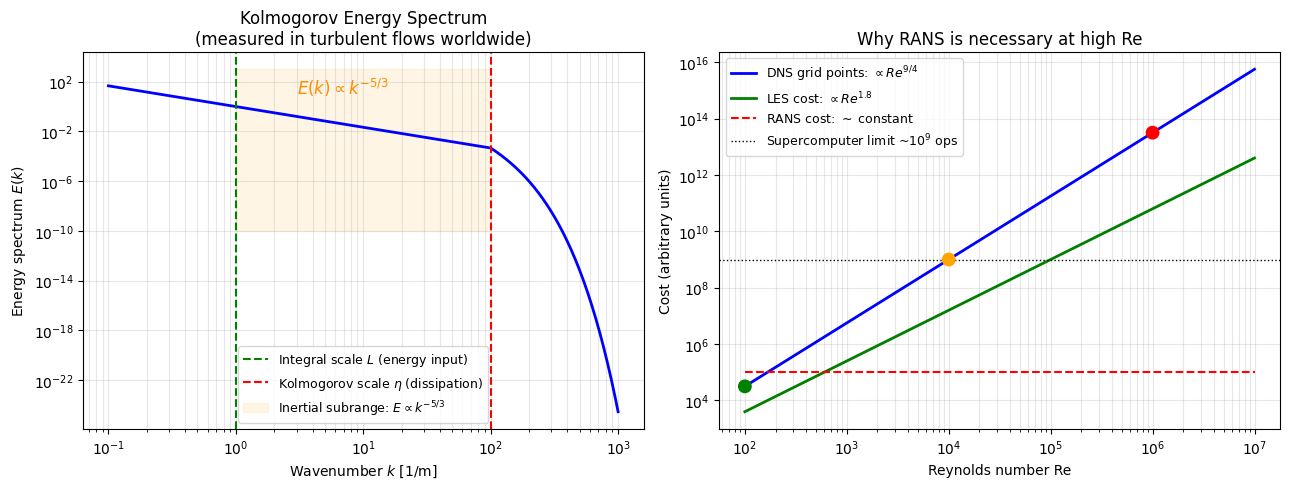

In [ ]:
# Kolmogorov -5/3 spectrum: E(k) ∝ k^(-5/3) in the inertial subrange
k = np.logspace(-1, 3, 500)
E = k**(-5/3)
E[k > 100] *= np.exp(-(k[k > 100] - 100) / 20)   # dissipation roll-off

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: energy spectrum
ax1.loglog(k, E, 'b-', lw=2)
ax1.axvline(1,   color='green', ls='--', lw=1.5, label='Integral scale $L$ (energy input)')
ax1.axvline(100, color='red',   ls='--', lw=1.5, label='Kolmogorov scale $\\eta$ (dissipation)')
ax1.fill_betweenx([1e-10, 1e3], 1, 100, alpha=0.1, color='orange', label='Inertial subrange: $E\\propto k^{-5/3}$')
ax1.text(3, 1e1, '$E(k) \\propto k^{-5/3}$', fontsize=12, color='darkorange')
ax1.set_xlabel('Wavenumber $k$ [1/m]'); ax1.set_ylabel('Energy spectrum $E(k)$')
ax1.set_title('Kolmogorov Energy Spectrum\n(measured in turbulent flows worldwide)')
ax1.legend(fontsize=9); ax1.grid(True, which='both', alpha=0.3)

# Right: DNS cost scaling
Re_arr = np.logspace(2, 7, 200)
ax2.loglog(Re_arr, Re_arr**(9/4), 'b-', lw=2, label='DNS grid points: $\\propto Re^{9/4}$')
ax2.loglog(Re_arr, Re_arr**(1.8), 'g-', lw=2, label='LES cost: $\\propto Re^{1.8}$')
ax2.loglog(Re_arr, Re_arr**0.0 * 1e5, 'r--', lw=1.5, label='RANS cost: $\\sim$ constant')
ax2.axhline(1e9, color='k', ls=':', lw=1, label='Supercomputer limit ~$10^9$ ops')
ax2.scatter([100, 1e4, 1e6], [100**(9/4), 1e4**(9/4), 1e6**(9/4)],
            c=['green','orange','red'], s=80, zorder=5)
ax2.set_xlabel('Reynolds number Re'); ax2.set_ylabel('Cost (arbitrary units)')
ax2.set_title('Why RANS is necessary at high Re')
ax2.legend(fontsize=9); ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Reynolds Decomposition

### The problem with turbulent signals

At a point in a turbulent flow, the velocity looks like this over time:

```
u(t)
1.4 |  *  * *   *    *  *   *
1.1 |*   *    * * * *    *   * *
0.8 |       *          *
    └──────────────────────────→ t
```

It oscillates randomly around a mean. We cannot solve the N-S equations for every fluctuation — that is exactly DNS. Instead, we **separate** the signal into two parts:

$$\phi(\mathbf{x}, t) = \underbrace{\bar{\phi}(\mathbf{x})}_{\text{time mean — steady}} + \underbrace{\phi'(\mathbf{x}, t)}_{\text{fluctuation — zero mean}}$$

$$\bar{\phi} = \lim_{T\to\infty}\frac{1}{T}\int_0^T \phi\,dt$$

### The four averaging rules (critical for RANS derivation)

| Rule | Expression | Why |
|---|---|---|
| Mean of fluctuation | $\overline{\phi'} = 0$ | Definition of mean |
| Mean of mean | $\bar{\bar{\phi}} = \bar{\phi}$ | Mean is already steady |
| Linearity | $\overline{\phi+\psi} = \bar{\phi}+\bar{\psi}$ | Integral is linear |
| **Products** | $\overline{\phi\,\psi} = \bar{\phi}\,\bar{\psi} + \overline{\phi'\psi'}$ | Non-trivial! |

The product rule is what makes turbulence hard. Even though $\overline{u'} = 0$ and $\overline{v'} = 0$, the correlation $\overline{u'v'}$ is generally **not zero** — and this is where all the difficulty lies.

### Why $\overline{u'v'} \neq 0$ — physical explanation

Near a wall, fast-moving fluid from the core is occasionally ejected toward the wall (a **sweep event**): this parcel has $u' > 0$ (faster than mean) and $v' < 0$ (moving toward wall). Product: $u'v' < 0$.

Slow-moving fluid near the wall is occasionally lifted away (**ejection event**): $u' < 0$, $v' > 0$. Product: $u'v' < 0$ again.

Both events produce $u'v' < 0$ → $\overline{u'v'} < 0$ near a wall. This is **turbulent momentum transport** — the flow actively mixes high and low momentum fluid.

### Measuring turbulence intensity

Since $\overline{u'} = 0$ always, we use the **RMS** (root-mean-square) to measure fluctuation strength:

$$u'_{\text{rms}} = \sqrt{\overline{u'^2}}$$

$$\text{Turbulence intensity} = \frac{u'_{\text{rms}}}{\bar{U}} \times 100\%$$

Typical values: pipe flow core ~3%, jet engine inlet ~5–10%, combustion chamber ~20–30%.

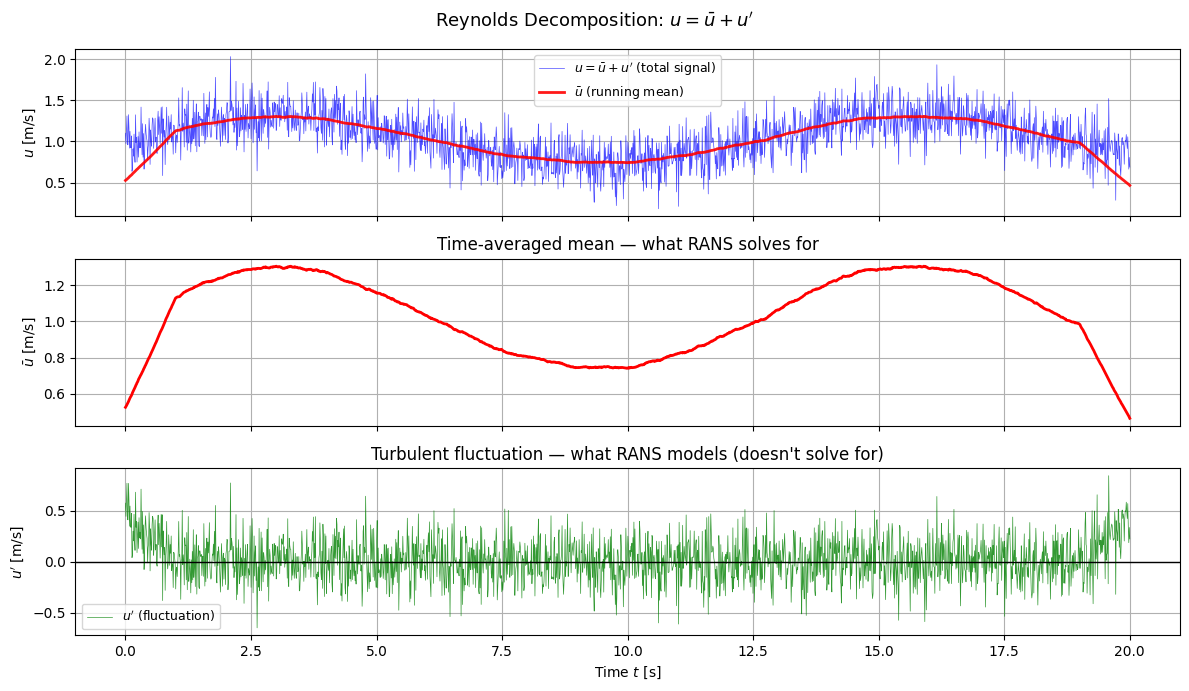

mean of u'  = 0.024117  ← should be ~0
RMS  of u'  = 0.2114   ← non-zero: real fluctuation energy
Turbulence intensity = 20.3%

Note: avg(u') = 0 always — useless as a measure of turbulence strength
      RMS(u') > 0 always — measures the actual energy in fluctuations


In [ ]:
# Reynolds decomposition on a synthetic turbulent signal
np.random.seed(42)
t = np.linspace(0, 20, 2000)
u_mean  = 1.0 + 0.3 * np.sin(0.5 * t)       # slow mean variation
u_prime = 0.2 * np.random.randn(len(t))       # turbulent fluctuation (white noise)
u_total = u_mean + u_prime

# Running time-average (window = 200 samples)
window = 200
u_bar = np.convolve(u_total, np.ones(window)/window, mode='same')
u_fluct = u_total - u_bar

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t, u_total, 'b-', lw=0.5, alpha=0.7, label='$u = \\bar{u} + u\'$ (total signal)')
axes[0].plot(t, u_bar,   'r-', lw=2,   alpha=0.9, label='$\\bar{u}$ (running mean)')
axes[0].set_ylabel('$u$ [m/s]'); axes[0].legend(fontsize=9); axes[0].grid(True)

axes[1].plot(t, u_bar, 'r-', lw=2)
axes[1].set_ylabel('$\\bar{u}$ [m/s]')
axes[1].set_title('Time-averaged mean — what RANS solves for')
axes[1].grid(True)

axes[2].plot(t, u_fluct, 'g-', lw=0.5, alpha=0.8, label="$u'$ (fluctuation)")
axes[2].axhline(0, color='k', lw=1)
axes[2].set_ylabel("$u'$ [m/s]")
axes[2].set_xlabel('Time $t$ [s]')
axes[2].set_title("Turbulent fluctuation — what RANS models (doesn't solve for)")
axes[2].legend(fontsize=9); axes[2].grid(True)

plt.suptitle('Reynolds Decomposition: $u = \\bar{u} + u\'$', fontsize=13)
plt.tight_layout(); plt.show()

TI = np.std(u_fluct) / np.mean(u_bar) * 100
print(f"mean of u'  = {np.mean(u_fluct):.6f}  ← should be ~0")
print(f"RMS  of u'  = {np.std(u_fluct):.4f}   ← non-zero: real fluctuation energy")
print(f"Turbulence intensity = {TI:.1f}%")
print()
print("Note: avg(u') = 0 always — useless as a measure of turbulence strength")
print("      RMS(u') > 0 always — measures the actual energy in fluctuations")

## 3. Deriving the RANS Equations — Step by Step

### Starting point: incompressible N-S momentum equation

$$\frac{\partial u_i}{\partial t} + \frac{\partial(u_i u_j)}{\partial x_j} = -\frac{1}{\rho}\frac{\partial p}{\partial x_i} + \nu\frac{\partial^2 u_i}{\partial x_j^2}$$

### Step 1: Substitute $u_i = \bar{u}_i + u_i'$, $p = \bar{p} + p'$

The linear terms are straightforward. The nonlinear convection term gives:

$$\frac{\partial(u_i u_j)}{\partial x_j} = \frac{\partial((\bar{u}_i+u_i')(\bar{u}_j+u_j'))}{\partial x_j} = \frac{\partial(\bar{u}_i\bar{u}_j)}{\partial x_j} + \frac{\partial(\bar{u}_i u_j')}{\partial x_j} + \frac{\partial(u_i'\bar{u}_j)}{\partial x_j} + \frac{\partial(u_i'u_j')}{\partial x_j}$$

### Step 2: Time-average the entire equation

Using the averaging rules: $\overline{\bar{u}_i u_j'} = \bar{u}_i \overline{u_j'} = 0$ (mean times zero-mean fluctuation).

Only two terms survive:

$$\overline{\frac{\partial(u_i u_j)}{\partial x_j}} = \frac{\partial(\bar{u}_i\bar{u}_j)}{\partial x_j} + \frac{\partial\overline{u_i'u_j'}}{\partial x_j}$$

### Step 3: The RANS momentum equation

$$\boxed{\frac{\partial \bar{u}_i}{\partial t} + \bar{u}_j\frac{\partial \bar{u}_i}{\partial x_j} = -\frac{1}{\rho}\frac{\partial \bar{p}}{\partial x_i} + \frac{\partial}{\partial x_j}\left[\nu\frac{\partial \bar{u}_i}{\partial x_j} - \overline{u_i'u_j'}\right]}$$

The **only difference** from laminar N-S: the extra term $-\overline{u_i'u_j'}$ — the **Reynolds stress tensor**.

$$\tau_{ij}^{\text{Re}} = -\rho\,\overline{u_i'u_j'} = -\rho\begin{pmatrix} \overline{u'u'} & \overline{u'v'} & \overline{u'w'} \\ \overline{v'u'} & \overline{v'v'} & \overline{v'w'} \\ \overline{w'u'} & \overline{w'v'} & \overline{w'w'} \end{pmatrix}$$

**Physical meaning of $-\rho\overline{u'v'}$:** rate of $x$-momentum transported in the $y$-direction by turbulent fluctuations. This is analogous to $\rho\nu\,\partial\bar{u}/\partial y$ (viscous stress) but driven by eddies, not molecules.

### The closure problem — why models are needed

Count unknowns vs equations for the mean flow:

| | Laminar N-S | RANS |
|---|---|---|
| Velocity components | $u, v, w$ = 3 | $\bar{u}, \bar{v}, \bar{w}$ = 3 |
| Pressure | $p$ = 1 | $\bar{p}$ = 1 |
| Reynolds stresses | — | $\overline{u_i'u_j'}$, 6 independent = **6** |
| **Total unknowns** | **4** | **10** |
| **Equations** | **4** | **4** |

RANS has **6 more unknowns than equations**. The system is not closed. This is the **turbulence closure problem** — it cannot be solved exactly without more physics or assumptions. Every turbulence model is a hypothesis about what $\overline{u_i'u_j'}$ looks like.

## 4. Boussinesq Hypothesis — Eddy Viscosity

### The analogy with molecular viscosity

In a laminar flow, the viscous stress tensor is:

$$\tau_{ij}^{\text{visc}} = 2\rho\nu\bar{S}_{ij}, \qquad \bar{S}_{ij} = \frac{1}{2}\left(\frac{\partial\bar{u}_i}{\partial x_j} + \frac{\partial\bar{u}_j}{\partial x_i}\right)$$

Boussinesq (1877) proposed: **turbulent stress has the same form**, just with a much larger effective viscosity $\nu_t$:

$$-\rho\overline{u_i'u_j'} = 2\rho\nu_t\bar{S}_{ij} - \frac{2}{3}\rho k\,\delta_{ij}$$

- $\nu_t$ = eddy viscosity — the turbulence model must provide this
- $\bar{S}_{ij}$ = mean strain rate tensor — computed from $\bar{u}$
- $k = \frac{1}{2}\overline{u_i'u_i'}$ = turbulent kinetic energy
- $\frac{2}{3}\rho k\,\delta_{ij}$ = isotropic part — added to match the trace ($\overline{u'^2}+\overline{v'^2}+\overline{w'^2} = 2k$), usually absorbed into a modified pressure

### What the hypothesis assumes

Boussinesq assumes turbulence is **isotropic** (equal in all directions) and **aligned with the mean strain**. This is a strong assumption. It works well for:
- Simple shear flows (pipe, channel, flat plate)
- Mild pressure gradients

It fails for:
- Strong curvature (bent pipes)
- Rotation (turbomachinery)
- Impingement (jet hitting a wall)
- Strongly separated flows

### What the turbulence model provides

With Boussinesq, 6 unknowns reduce to 1: **find $\nu_t(\mathbf{x})$**.

The model must give $\nu_t$ at every point in the domain. Different models use different strategies — algebraic (mixing-length), one transport equation (SA), two transport equations ($k$–$\varepsilon$, $k$–$\omega$ SST).

## 5. Prandtl Mixing-Length Model

### Physical derivation from first principles

Imagine a fluid parcel at height $y$ above a wall. It is displaced vertically by a turbulent fluctuation, travelling a distance $\ell_m$ before it mixes with its new surroundings.

During travel, it keeps its original momentum. The velocity difference between its origin ($y$) and destination ($y + \ell_m$) is approximately:

$$u' \approx \ell_m \left|\frac{d\bar{u}}{dy}\right| \qquad \text{(momentum carried during mixing length travel)}$$

Similarly, the vertical fluctuation: $v' \sim u'$ (same order of magnitude by continuity).

The Reynolds shear stress:

$$|{-\overline{u'v'}}| \sim u' \cdot v' \sim \ell_m^2\left(\frac{d\bar{u}}{dy}\right)^2$$

Comparing with the Boussinesq formula $-\overline{u'v'} = \nu_t\,d\bar{u}/dy$:

$$\boxed{\nu_t = \ell_m^2\left|\frac{d\bar{u}}{dy}\right|}$$

### Near-wall mixing length: $\ell_m = \kappa y$

A parcel at height $y$ cannot travel more than $y$ before hitting the wall. So $\ell_m \propto y$ near the wall. The constant $\kappa = 0.41$ (von Kármán constant) is universal — measured in pipe flows, channel flows, boundary layers, and atmospheric boundary layers worldwide.

### Van Driest damping — physics of the viscous sublayer

Right at the wall, the no-penetration condition ($v = 0$) suppresses $v'$, killing turbulence. The Van Driest correction accounts for this:

$$\ell_m = \kappa y\left(1 - e^{-y^+/A^+}\right), \quad A^+ = 26$$

- At $y^+ = 0$: $\ell_m = 0 \implies \nu_t = 0$ — only molecular viscosity acts
- At $y^+ \gg 26$: $\ell_m \to \kappa y$ — log-law region
- The exponential damps $\ell_m$ smoothly through the buffer layer

### The log-law as a consequence

In steady channel flow, the shear stress is constant: $\nu_t\,d\bar{u}/dy = u_\tau^2$.
With $\nu_t = (\kappa y)^2 |d\bar{u}/dy|$ in the log-law region:

$$(\kappa y)^2\left(\frac{d\bar{u}}{dy}\right)^2 \cdot \frac{d\bar{u}/dy}{d\bar{u}/dy} = u_\tau^2 \implies \frac{d\bar{u}}{dy} = \frac{u_\tau}{\kappa y}$$

Integrating: $\bar{u} = \frac{u_\tau}{\kappa}\ln y + C$, or in wall units:

$$\boxed{u^+ = \frac{1}{\kappa}\ln y^+ + B} \qquad \kappa = 0.41, \quad B = 5.2$$

The log-law is derived purely from the mixing-length hypothesis near a wall. It has been validated in thousands of experiments and is one of the most robust results in turbulence.

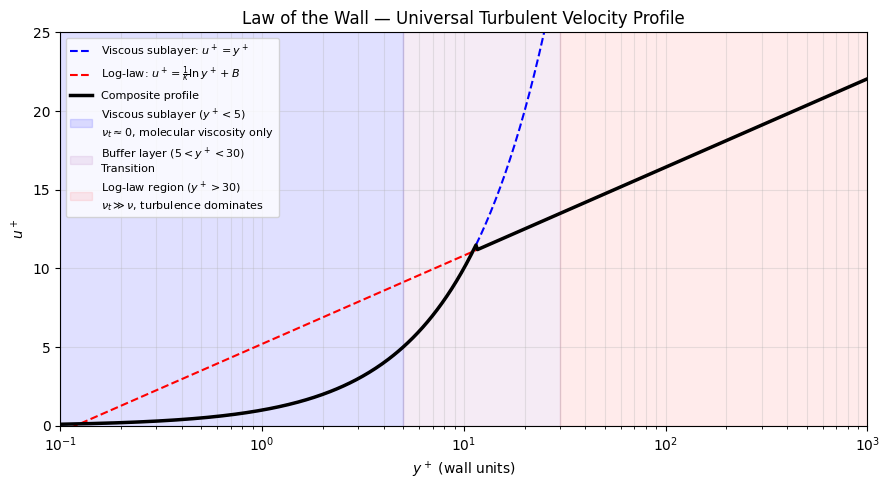

y+    |  u+   | Region
-----------------------------------
  1.0 |  1.00 | Viscous
  5.0 |  5.00 | Buffer
 11.6 | 11.18 | Buffer
 30.0 | 13.50 | Log-law
100.0 | 16.43 | Log-law
300.0 | 19.11 | Log-law


In [ ]:
# Law of the Wall — three regions visualised
kappa = 0.41; B = 5.2
y_plus = np.logspace(-1, 3, 500)

u_visc  = y_plus                                       # viscous sublayer: u+ = y+
u_log   = (1/kappa) * np.log(y_plus) + B               # log-law
u_comp  = np.where(y_plus < 11.6, u_visc, u_log)      # composite (intersection at y+≈11.6)

plt.figure(figsize=(9, 5))
plt.semilogx(y_plus, u_visc,  'b--', lw=1.5, label='Viscous sublayer: $u^+=y^+$')
plt.semilogx(y_plus, u_log,   'r--', lw=1.5, label='Log-law: $u^+=\\frac{1}{\\kappa}\\ln y^+ + B$')
plt.semilogx(y_plus, u_comp,  'k-',  lw=2.5, label='Composite profile')
plt.axvspan(0.1,  5,  alpha=0.12, color='blue',   label='Viscous sublayer ($y^+<5$)\n$\\nu_t \\approx 0$, molecular viscosity only')
plt.axvspan(5,   30,  alpha=0.08, color='purple',  label='Buffer layer ($5<y^+<30$)\nTransition')
plt.axvspan(30, 1000, alpha=0.08, color='red',    label='Log-law region ($y^+>30$)\n$\\nu_t \\gg \\nu$, turbulence dominates')
plt.xlabel('$y^+$ (wall units)'); plt.ylabel('$u^+$')
plt.title('Law of the Wall — Universal Turbulent Velocity Profile')
plt.legend(fontsize=8, loc='upper left'); plt.grid(True, which='both', alpha=0.3)
plt.xlim([0.1, 1000]); plt.ylim([0, 25])
plt.tight_layout(); plt.show()

# Physical interpretation:
y_plus_check = np.array([1, 5, 11.6, 30, 100, 300])
u_check = np.where(y_plus_check < 11.6, y_plus_check, (1/kappa)*np.log(y_plus_check)+B)
print('y+    |  u+   | Region')
print('-'*35)
for yp, up in zip(y_plus_check, u_check):
    region = 'Viscous' if yp<5 else ('Buffer' if yp<30 else 'Log-law')
    print(f'{yp:5.1f} | {up:5.2f} | {region}')

## 6. Turbulence Models — Overview

### The hierarchy of closures

Every model makes a trade-off between **cost** and **physical fidelity**:

```
More physics ↑
              DNS    — resolve everything, cost ∝ Re³
              LES    — resolve large eddies, model small ones
              RSM    — 7 transport equations for all stresses
              k-ω SST — 2 equations, best near-wall + free stream
              k-ε    — 2 equations, good away from walls
              SA     — 1 equation, aerodynamics
              Mixing-length — 0 equations, simple shear only
Cheaper  ↓
```

| Model | Transport eq | $\nu_t$ formula | Best for | Failure |
|---|---|---|---|---|
| Mixing-length | 0 | $\ell_m^2\lvert d\bar{u}/dy\rvert$ | Simple shear, teaching | Only 1D shear |
| Spalart–Allmaras | 1 ($\tilde{\nu}$) | $\tilde{\nu}\,f_{v1}$ | Aerodynamic BLs | Free shear flows |
| $k$–$\varepsilon$ | 2 ($k, \varepsilon$) | $C_\mu k^2/\varepsilon$ | Free jets, wake | Near-wall singular |
| $k$–$\omega$ SST | 2 ($k, \omega$) | Blended | **Industry default** | Complex geometry |
| RSM | 7 ($\tau_{ij}$) | Direct transport | Swirl, curvature | Expensive, fragile |
| LES | filtered NS | SGS model | Unsteady structures | Cost $\sim Re^{1.8}$ |
| DNS | full NS | none | Research, Re<10,000 | Cost $\sim Re^3$ |

### Connection to what you have already built

Your cavity and cylinder solvers (Modules 2.14–2.15) were laminar DNS at Re=100. To run them at Re=10,000 you would either:
- Add a turbulence model (RANS approach, Module 3.18)
- Use a much finer grid and run a proper DNS (~180×180 for Re=1,000)

The turbulence model replaces the need to resolve the small eddies. Instead of computing what the eddies do, the model **tells the solver** their net effect on the mean flow via $\nu_t$.

## Summary

| Concept | Physics | Formula |
|---|---|---|
| Kolmogorov scale | Smallest eddy — Re=1, viscosity acts | $\eta = (\nu^3/\varepsilon)^{1/4} \sim L\,Re^{-3/4}$ |
| DNS cost | Every eddy resolved | $\sim Re^3$ — infeasible for Re>10,000 in 3D |
| Reynolds decomp. | Split mean + fluctuation | $u = \bar{u} + u'$, $\overline{u'}=0$ |
| Reynolds stress | Turbulent momentum transport | $\tau_{ij}^{\text{Re}} = -\rho\overline{u_i'u_j'}$ |
| Closure problem | 10 unknowns, 4 equations | Need 6 extra equations or a model |
| Boussinesq | Turbulence acts like viscosity | $-\rho\overline{u_i'u_j'} = 2\rho\nu_t\bar{S}_{ij}$ |
| Mixing length | Parcel travels $\ell_m$ before mixing | $\nu_t = \ell_m^2|d\bar{u}/dy|$ |
| Van Driest | Wall kills $v'$ → $\nu_t \to 0$ | $\ell_m = \kappa y(1 - e^{-y^+/A^+})$ |
| Log-law | Consequence of mixing-length near wall | $u^+ = (1/\kappa)\ln y^+ + B$ |

**Key physical insight to carry forward:**
Turbulence is not just noise — it has a precise structure (energy cascade), and its effect on the mean flow is entirely captured by the Reynolds stress $-\rho\overline{u_i'u_j'}$. Every turbulence model is an attempt to compute this stress without resolving every eddy individually.